<a href="https://colab.research.google.com/github/camiloch28/landing_experiment_synthetic-analysis/blob/main/landing-experiment-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Realizar analisis estadistico con T-Test o T de Student

In [ ]:
# Comenzamos importando librerías e incluimos la función ttest_ind, que es la que nos permite realizar la prueba t de Student.
import pandas as pd
from scipy.stats import ttest_ind

# Cargar el dataset del experimento
df = pd.read_csv("/content/landing_experiment_synthetic.csv")
df.head()

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
0,99aa92e9-6dc3-4b18-8a31-fb1442e71d67,A,Norte,Desktop,0,0.00,0
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,1,102.86,92
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,0,0.00,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,0,0.00,0
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,1,76.38,68


Nuestro objetivo es comparar el gasto promedio entre usuarios de la página  A y la página  B. Entonces separamos en estos grupos.

In [ ]:
# Separar en grupo A y grupo B
grupo_A = df[(df['pagina'] == 'A')]
grupo_B= df[(df['pagina'] == 'B')]
grupo_B.head()

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,1,102.86,92
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,0,0.00,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,0,0.00,0
7,0e4d3c5f-5520-4328-897d-ef007bcdddea,B,Norte,Desktop,0,0.00,0
8,5992c5a1-554c-4e03-9b25-b2dd107266ed,B,Norte,Mobile,1,66.89,60


Observa que algunos usuarios no se convirtieron en clientes y tienen gasto cero. Dado que no nos interesan, agregamos una segunda condición para filtrar a los que sí compraron. Este paso es clave: no tendría sentido comparar el gasto de usuarios que no compraron.

In [ ]:
# Separar en grupo A y grupo B
grupo_A = df[(df['pagina'] == 'A') & (df['conversion'] == 1)]
grupo_B= df[(df['pagina'] == 'B') & (df['conversion'] == 1)]
grupo_B.head()

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,1,102.86,92
8,5992c5a1-554c-4e03-9b25-b2dd107266ed,B,Norte,Mobile,1,66.89,60
25,a6837336-3457-44e6-887a-4bd3ffe9b1b7,B,Centro,Desktop,1,56.18,56
27,c586a60b-e26b-4606-b50d-d70da5d52aad,B,Sur,Desktop,1,94.32,94
30,a526bc4d-bf5b-4b95-bbd4-d7972b110c5d,B,Centro,Desktop,1,63.38,63


Comprobamos que tenemos la información que nos interesa y seleccionamos únicamente la columna del gasto, que es la que queremos evaluar.

In [ ]:
# Separar en grupo A y grupo B
grupo_A = df[(df['pagina'] == 'A') & (df['conversion'] == 1)]['gasto']
grupo_B= df[(df['pagina'] == 'B') & (df['conversion'] == 1)]['gasto']
grupo_B.head()

,gasto
1,102.86
8,66.89
25,56.18
27,94.32
30,63.38


Con nuestros grupos listos, ejecutamos la función ttest_ind y le pasamos ambos grupos como entrada.

In [ ]:
ttest_ind(grupo_A, grupo_B)

TtestResult(statistic=np.float64(-20.74768675846578), pvalue=np.float64(1.4282455772283151e-90), df=np.float64(3722.0))

Observa que el resultado tiene dos elementos, uno llamado statistic y el pvalue.

Para hacerlo más legible, los guardamos y los mostramos junto con un texto más explicativo.

In [ ]:
# Ejecutar prueba t y guardar resultados
t_stat, p_value = ttest_ind(grupo_A, grupo_B)

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor P: {p_value}")

Estadístico t: -20.74768675846578
Valor P: 1.4282455772283151e-90


#2. Interpretando prueba T de Student

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# Cargamos el dataset del experimento
df = pd.read_csv("/content/landing_experiment_synthetic.csv")
df.head()

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
0,99aa92e9-6dc3-4b18-8a31-fb1442e71d67,A,Norte,Desktop,0,0.00,0
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,1,102.86,92
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,0,0.00,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,0,0.00,0
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,1,76.38,68


Filtramos el dataset para quedarnos solo con los usuarios que

realmente compraron, es decir, los que tienen 1 en la columna conversión,
y separamos en dos grupos, los usuarios de dispositivos Desktop y Mobile.
En esta ocasión analizaremos la cantidad de clics que cada uno de los usuarios hizo en la página.

In [ ]:
# Separar en dos grupos
clics_desktop = df[(df['conversion'] == 1) & (df['dispositivo']== 'Desktop')]['clics']
clics_mobile = df[(df['conversion'] == 1) & (df['dispositivo']== 'Mobile')]['clics']

clics_mobile.head()

,clics
1,92
4,68
8,60
19,61
29,59


Finalmente, aplicamos la prueba y obtenemos los resultados de la prueba t de Student.

In [ ]:
# Ejecutar prueba t y mostrar resultados
t_stat, p_value = ttest_ind(clics_desktop, clics_mobile)

print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

Estadístico t: 11.995253798271609
Valor p: 1.4876511237993493e-32


¿Qué significan estos valores?

El valor p es el que guía la decisión. Lo comparamos con alpha de 0.05, que representa un 5% de riesgo.

Si el valor p es menor a alpha, rechazamos la hipótesis nula,
pero si el valor p es mayor o igual, no tenemos evidencia suficiente para rechazarla.

In [ ]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


Ejecutamos el código y vemos que se rechaza la hipótesis nula.

Es decir, tenemos evidencia estadística para afirmar que un dispositivo tiene más clics que el otro.

En estadística, el valor p dice si hay diferencia, pero no hacia donde ni qué tan grande es.

Para saber esto, primero calculamos los promedios de cada grupo y después los restamos para saber que tanto difieren.

In [ ]:
# Calcular promedios
media_desktop = clics_desktop.mean()
media_mobile = clics_mobile.mean()

print('La media para desktop es: ', media_desktop)
print('La media para mobile es: ', media_mobile)
print('La diferencia es de: ', media_desktop - media_mobile)

La media para desktop es:  60.827754108338404
La media para mobile es:  54.97357039884671
La diferencia es de:  5.854183709491693


En conclusión, el análisis indica que los dispositivos móviles registran en promedio alrededor de 5.8 clics menos que los de escritorio.

Este resultado nos da una diferencia clara. Ahora el siguiente paso sería evaluar qué tan relevante es esto para el negocio.

#Analisis de Varianza

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# Cargamos el dataset del experimento
df = pd.read_csv("/content/landing_experiment_synthetic.csv")
df.head()

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
0,99aa92e9-6dc3-4b18-8a31-fb1442e71d67,A,Norte,Desktop,0,0.00,0
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,1,102.86,92
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,0,0.00,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,0,0.00,0
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,1,76.38,68


En esta ocasión, filtramos el dataset para quedarnos con los usuarios que compraron y que son de la región centro.

In [ ]:
df_filtrado = df[(df['conversion'] == 1) & (df['region'] == 'Centro')]
df_filtrado.head()

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,1,76.38,68
23,95140ec1-6763-4fbb-96b1-c9d6ccc2e93f,A,Centro,Desktop,1,48.39,48
25,a6837336-3457-44e6-887a-4bd3ffe9b1b7,B,Centro,Desktop,1,56.18,56
30,a526bc4d-bf5b-4b95-bbd4-d7972b110c5d,B,Centro,Desktop,1,63.38,63
38,0b3086ff-d7c9-4a3c-be6c-0b7f780996ca,B,Centro,Mobile,1,63.94,57


A ese mismo código, le agregamos una tercer condición para separar a los usuarios en dos grupos, los usuarios de dispositivos Desktop y Mobile y seleccionamos la columna clics de cada grupo.

In [ ]:
# Separar en dos grupos
clics_desktop = df[(df['conversion'] == 1) & (df['region'] == 'Centro') & (df['dispositivo']== 'Desktop')]['clics']
clics_mobile = df[(df['conversion'] == 1) & (df['region'] == 'Centro') & (df['dispositivo']== 'Mobile')]['clics']

clics_mobile.head()

,clics
4,68
38,57
42,70
50,58
61,40



Hasta ahora hemos asumido que ambos grupos tienen una variabilidad similar.

Esto se debe a que ttest_ind usa por defecto equal_var=True, es decir, la prueba t asume varianzas iguales.

Sin embargo, en la práctica, esto no siempre se cumple.

In [ ]:
# estructura prueba t
ttest_ind(clics_desktop, clics_mobile, equal_var=True)

TtestResult(statistic=np.float64(6.238437826249554), pvalue=np.float64(5.957517771228438e-10), df=np.float64(1307.0))

Para verificar esto, antes de aplicar una prueba t, podemos realizar una prueba de varianzas iguales,  donde

la hipótesis nula establece que las varianzas de ambos grupos son iguales.
y la hipótesis alterna dice que las varianzas son diferentes.
Observa que la estructura es muy similar a la de la prueba t: le pasamos los datos de cada grupo y la prueba nos devuelve un estadístico y un valor p, que usaremos para tomar una decisión.

In [ ]:
from scipy.stats import levene

# Prueba de varianzas iguales
l_stat, p_value_var = levene(clics_desktop, clics_mobile)

print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p: {p_value_var}")

Estadístico de Levene: 11.824747635224542
Valor p: 0.0006028752988714592


A este código le agregamos la misma lógica que usamos para automatizar la interpretación de la prueba t, pero adaptando el texto para decidir si las varianzas son iguales o diferentes.

In [ ]:
alpha = 0.05  # umbral de significancia

if p_value_var < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).")

Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).


El resultado rechaza la hipótesis nula, sin esta prueba, habríamos usado incorrectamente la prueba t.

Continuamos con la prueba t estableciendo el parámetro equal_var=False.

In [ ]:
# Ejecutar prueba t y mostrar resultados
t_stat, p_value = ttest_ind(clics_desktop, clics_mobile, equal_var=False)

print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")
print()

alpha = 0.05   # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico t: 6.172057672784738
Valor p: 9.195201448983439e-10

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


Vemos que hay evidencia de una diferencia, entonces pasamos a comparar los promedios.

In [ ]:
# Calcular promedios
media_desktop = clics_desktop.mean()
media_mobile = clics_mobile.mean()

print('La media para desktop en la región centro es: ', media_desktop)
print('La media para mobile en la región centro es: ', media_mobile)
print('La diferencia es de: ', media_desktop - media_mobile)

La media para desktop en la región centro es:  60.61461794019934
La media para mobile en la región centro es:  55.51060820367751
La diferencia es de:  5.104009736521824


#3. Prueba z para comparar proporciones

In [ ]:
#Comenzamos importando librerías e incluimos la función proportions_ztest.
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

df = pd.read_csv("/content/landing_experiment_synthetic.csv")
df.head(10)

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
0,99aa92e9-6dc3-4b18-8a31-fb1442e71d67,A,Norte,Desktop,0,0.00,0
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,1,102.86,92
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,0,0.00,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,0,0.00,0
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,1,76.38,68
5,6a2b135a-9980-4915-8064-ae0bfb650ef2,A,Norte,Mobile,0,0.00,0
6,8930e88c-944d-4912-bf86-d81ae2400f51,A,Norte,Mobile,0,0.00,0
7,0e4d3c5f-5520-4328-897d-ef007bcdddea,B,Norte,Desktop,0,0.00,0
8,5992c5a1-554c-4e03-9b25-b2dd107266ed,B,Norte,Mobile,1,66.89,60
9,a8dc9f30-89fa-46e6-8287-7d31b1acc2d8,B,Norte,Mobile,0,0.00,0


Para obtener el porcentaje o proporción, primero necesitamos saber cuantos usuarios, de cada página, sí se convirtieron en clientes.

Observa que en la columna conversion tenemos unos y ceros. Si sumamos esa columna, estamos sumando o contando esos unos y obtenemos el total de usuarios que se convirtieron a clientes.

In [ ]:
conversiones = df.groupby('pagina')['conversion'].sum()
conversiones

,conversion
pagina,
A,1626
B,2098


Ahora, necesitamos el total de usuarios de cada página.

In [ ]:
totales = df.groupby('pagina')['conversion'].count()
totales

,conversion
pagina,
A,12438
B,12562


Ya tenemos la información, pero todavía no está en el formato que la prueba Z necesita.

Por eso, el siguiente paso es organizar los datos en listas: una con el número de éxitos

In [ ]:
exitos = [conversiones['A'], conversiones['B']]
exitos

[np.int64(1626), np.int64(2098)]

y otra con el total de observaciones por grupo.



In [ ]:
observaciones = [totales['A'], totales['B']]
observaciones

[np.int64(12438), np.int64(12562)]

A continuación, aplicamos la función proportions_ztest que nos devuelve dos valores clave: el estadístico Z y el valor p.

In [ ]:
# Aplicar prueba y visualizar resultados
z_stat, p_value = proportions_ztest(exitos , observaciones)

print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -8.056205645899977
Valor p: 7.869918925208132e-16


Con estos resultados, automatizamos la comparación contra el umbral del 5% y obtenemos directamente la interpretación.

In [ ]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


En este caso, el valor p es muy chico y es menor al umbral, entonces tenemos evidencia suficiente para rechazar la hipótesis nula.

Esto nos confirma que la diferencia en la conversión no es casualidad y podemos informar al equipo que una de las páginas es estadísticamente superior a la otra con un 95% de confianza.

# Aplicar la prubea z cuando la columna esta en formato texto (si / no)

In [ ]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

df = pd.read_csv("/content/landing_experiment_synthetic_2.csv")
df.head()

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
0,99aa92e9-6dc3-4b18-8a31-fb1442e71d67,A,Norte,Desktop,No,0.00,0
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,Si,102.86,92
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,No,0.00,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,No,0.00,0
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,Si,76.38,68


Observa que la columna binaria conversion tiene textos, no números. En este caso, no podemos sumarlos para obtener el número de éxitos.

La primera opción para esto es: primero filtrar los éxitos y después contarlos.

Comenzamos filtrando y nos quedamos únicamente con los registros de los usuarios que sí se convirtieron en clientes, es decir, los que tienen el texto Si, en la columna conversión.

In [ ]:
#Opción 1: Filtrar y contar los éxitos
df_filtrado = df[df['conversion'] == "Si"]
df_filtrado.head()

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,Si,102.86,92
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,Si,76.38,68
8,5992c5a1-554c-4e03-9b25-b2dd107266ed,B,Norte,Mobile,Si,66.89,60
19,d6ee3314-53e9-4926-90c0-382dd8671bb3,A,Sur,Mobile,Si,68.02,61
23,95140ec1-6763-4fbb-96b1-c9d6ccc2e93f,A,Centro,Desktop,Si,48.39,48


Después, podemos simplemente agrupar por página y contar la cantidad de éxitos en cada grupo.

In [ ]:
# Contar número de exitos
conversiones_1 = df_filtrado.groupby('pagina')['conversion'].count()
conversiones_1

,conversion
pagina,
A,1626
B,2098


Otra opción, sería primero reemplazar los valores Si por 1 y los No por 0, para trabajar con una variable binaria numérica.

In [ ]:
#Opción 2: Reemplazar y sumar
# Codificar columna
df['conversion_num'] = df['conversion'].replace({'Si': 1, 'No': 0})
df.head()

/tmp/ipykernel_1692/3675859753.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['conversion_num'] = df['conversion'].replace({'Si': 1, 'No': 0})


,id_usuario,pagina,region,dispositivo,conversion,gasto,clics,conversion_num
0,99aa92e9-6dc3-4b18-8a31-fb1442e71d67,A,Norte,Desktop,No,0.00,0,0
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,Si,102.86,92,1
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,No,0.00,0,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,No,0.00,0,0
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,Si,76.38,68,1


Después de reemplazar, la columna tiene valores de 1 o 0 y podemos pasar a sumar los unos.

In [ ]:
# Contar número de exitos
conversiones_2 = df.groupby('pagina')['conversion_num'].sum()
conversiones_2

,conversion_num
pagina,
A,1626
B,2098


Observa que ambos procesos dan exactamente el mismo resultado y podríamos usar cualquiera de los dos.

Con el conteo de éxitos listo, pasamos a contar el número total de registros.

In [ ]:
totales = df.groupby('pagina')['conversion'].count()
totales

,conversion
pagina,
A,12438
B,12562


Seguimos con el proceso que ya conocemos.

Pasamos los valores anteriores a formato lista, usando cualquiera de los resultados del conteo de éxitos.

In [ ]:
# Pasar los valores a formato lista
exitos = [conversiones_1['A'], conversiones_1['B']]
observaciones = [totales['A'], totales['B']]
observaciones

[np.int64(12438), np.int64(12562)]

Para finalmente, aplicar la prueba z con ayuda del código que ya habíamos usado.



In [ ]:
# Aplicar prueba y visualizar resultados
z_stat, p_value = proportions_ztest(exitos , observaciones)
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico z: -8.056205645899977
Valor p: 7.869918925208132e-16
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


Los resultados, nos muestran que se rechaza la hipótesis nula y hay evidencia para decir que la tasa de éxito entre ambas páginas es diferente.

Sin embargo, ahora surge una nueva pregunta: ¿Cuál de las dos páginas da mejores resultados?

Para esto, tenemos que revisar la dirección, es decir, cual página convierte mejor.

Para ver el porcentaje o proporción, dividimos la cantidad de éxitos entre el total de observaciones.

Para tomarlos directamente del resultado, le decimos a Python que seleccione el elemento 0 de éxitos y que lo divida entre el elemento 0 de observaciones.

Al dividir estos datos, obtenemos la tasa de éxito de la página A.

In [ ]:
tasa_A = exitos[0] / observaciones[0]
tasa_A

np.float64(0.13072841292812348)

Hacemos lo mismo con la página B y nos apoyamos de un “F string” para formatear el resultado a un porcentaje de dos decimales.

In [ ]:
tasa_B = exitos[1] / observaciones[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

Tasa de conversión página A: 13.07%
Tasa de conversión página B: 16.70%


Al ver los resultados, podemos saber qué página tiene una mejor tasa, pero podemos automatizar este proceso:

Si el valor de A es mayor que el B, decimos que la página A tiene una mejor conversión.
Si ocurre lo contrario, entonces B da mejores resultados.
El else cubre el caso en que las tasas son iguales, aunque en la práctica casi nunca ocurre.
Internamente, la prueba z hace una comparación parecida, pero considerando la variabilidad y el tamaño de la muestra, para calcular el valor p.

In [ ]:
if tasa_A > tasa_B:
    print(f"\nLa página A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nLa página B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")


La página B tiene una mayor tasa de conversión (3.63%)


#4. Prueba chi - cuadrado para validar relaciones entre variables categoricas

Recordemos que es una tabla de contingencia.

En los datos tenemos muchos usuarios, cada uno con un dispositivo y un resultado: compró o no compró. Esto no dice mucho sobre la relación entre las variables; por eso necesitamos resumir en una tabla de conteos.

In [1]:
import pandas as pd

df = pd.read_csv("/content/landing_experiment_synthetic.csv")
df.head()

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
0,99aa92e9-6dc3-4b18-8a31-fb1442e71d67,A,Norte,Desktop,0,0.00,0
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,1,102.86,92
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,0,0.00,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,0,0.00,0
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,1,76.38,68


Como punto de partida, contamos la cantidad total de usuarios que se convirtieron en clientes con value_counts().

Podemos ver cuántos compraron y cuántos no.

In [2]:
df['conversion'].value_counts()

,count
conversion,
0,21276
1,3724


Agregamos el dispositivo a nuestra lista de columnas para value_counts().

Vemos cuatro filas, 2 para los no convertidos y 2 para los que sí. Ambos separados por dispositivo en la primera columna.

In [3]:
df[['dispositivo','conversion']].value_counts()

,,count
dispositivo,conversion,
Mobile,0,12852
Desktop,0,8424
Mobile,1,2081
Desktop,1,1643


La tabla de contingencia lo que hace es 'limpiar' este resultado.

Agrupa los usuarios por su primera característica, en este caso, su dispositivo.
Luego, dentro de cada grupo, cuenta cuántos se convirtieron para crear coordenadas.

Observa que tenemos los mismos valores que con el value_counts() pero más resumidos.

In [4]:
tabla = pd.crosstab( df["dispositivo"], df["conversion"])
tabla

conversion,0,1
dispositivo,,
Desktop,8424,1643
Mobile,12852,2081


Al final, pasamos de muchas filas a solo cuatro números clave. Esta cuadrícula es el mapa que la prueba chi-cuadrada usará para decirnos si la distribución es normal o si hay algo sospechoso.

Ahora que ya tenemos la tabla de contingencia, podemos buscar patrones normalizando la tabla por filas.

Con normalize='index', cada fila suma 1, lo que nos permite comparar dispositivos y ver cómo se distribuye la conversión en cada caso.



In [5]:
pd.crosstab(df['dispositivo'], df['conversion'], normalize='index')

conversion,0,1
dispositivo,,
Desktop,0.836793,0.163207
Mobile,0.860644,0.139356


Si multiplicamos por 100, pasamos a porcentajes y los patrones se vuelven más evidentes.

Vemos que la conversión es ligeramente mayor en Desktop que en Mobile: alrededor del 16% contra un 14%.

In [6]:
pd.crosstab(df['dispositivo'], df['conversion'], normalize='index') * 100


conversion,0,1
dispositivo,,
Desktop,83.679348,16.320652
Mobile,86.064421,13.935579


#Veamos cómo aplicar la prueba chi-cuadrada en Python para evaluar si la conversión depende del dispositivo.

In [7]:
import pandas as pd
from scipy.stats import chi2_contingency

df = pd.read_csv("/content/landing_experiment_synthetic.csv")
df.head()

,id_usuario,pagina,region,dispositivo,conversion,gasto,clics
0,99aa92e9-6dc3-4b18-8a31-fb1442e71d67,A,Norte,Desktop,0,0.00,0
1,99182f6f-325f-499a-815e-5ad414fe1600,B,Norte,Mobile,1,102.86,92
2,774a1f0c-eadb-4c1e-ae10-3058c9594162,B,Centro,Mobile,0,0.00,0
3,6bcc6b1b-56ee-4a7c-b478-01147c2d2cf9,B,Sur,Desktop,0,0.00,0
4,b22abbb3-9919-4974-9288-41212563492c,A,Centro,Mobile,1,76.38,68


Después, resumimos los datos en una tabla de contingencia sin normalizar. Recordemos que la prueba necesita los conteos, no porcentajes.

In [8]:
tabla = pd.crosstab(df['dispositivo'], df['conversion'])
tabla

conversion,0,1
dispositivo,,
Desktop,8424,1643
Mobile,12852,2081


Luego, pasamos a aplicar la prueba chi-cuadrada que recibe la tabla de contingencia.

In [9]:
chi2_contingency(tabla)

Chi2ContingencyResult(statistic=np.float64(26.795218858008006), pvalue=np.float64(2.261962800740092e-07), dof=1, expected_freq=array([[ 8567.41968,  1499.58032],
       [12708.58032,  2224.41968]]))

Como en casos anteriores, nos apoyamos de f strings para entender mejor los resultados:

In [10]:
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 26.795
Valor P: 0.000
Grados de libertad: 1

Frecuencias esperadas:
[[ 8567.41968  1499.58032]
 [12708.58032  2224.41968]]


La prueba devuelve 4 elementos:

el estadístico chi-cuadrado, que mide qué tan diferentes son los conteos observados respecto a los esperados,
el valor p, que indica si la diferencia es estadísticamente significativa,
los grados de libertad usados para calcular los resultados,
y la tabla de frecuencias esperadas. Esta representa cuántos casos esperaríamos en cada combinación si las variables fueran independientes.
Finalmente, agregamos el código conocido para automatizar la interpretación.



In [11]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


El valor p es pequeño, por lo que rechazamos la hipótesis nula y concluimos que existe evidencia de asociación entre el dispositivo y la conversión,

In [12]:
# Tabla de contingencia normalizada
pd.crosstab(df['dispositivo'], df['conversion'], normalize='index') * 100

conversion,0,1
dispositivo,,
Desktop,83.679348,16.320652
Mobile,86.064421,13.935579


Confirmando el patrón que observamos en la tabla de contingencia normalizada: los dispositivos Desktop presentan una conversión ligeramente mayor que Mobile.

#5.1.  Gráfico de barras agrupadas en **Python**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/content/landing_experiment_synthetic_3.csv")

# 1. Creamos la tabla de contingencia
tabla = pd.crosstab(df['dispositivo'], df['conversion'])
tabla

conversion,0,1
dispositivo,,
Desktop,8416,1642
Mobile,12851,2080
Smart Speaker,2,4
Smart TV,3,2


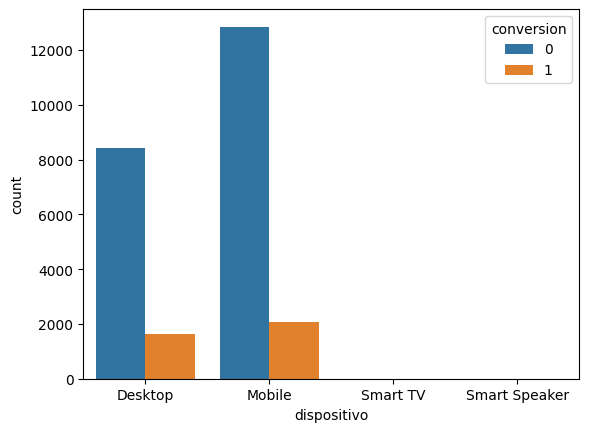

In [2]:
# Gráfico de barras agrupadas
sns.countplot(data=df, x='dispositivo', hue='conversion')
plt.show()

Después agregamos más detalles como

Agrandar la gráfica.
Un estilo de colores consistente con los colores del negocio.
Título y ejes horizontal y vertical.
Una leyenda.

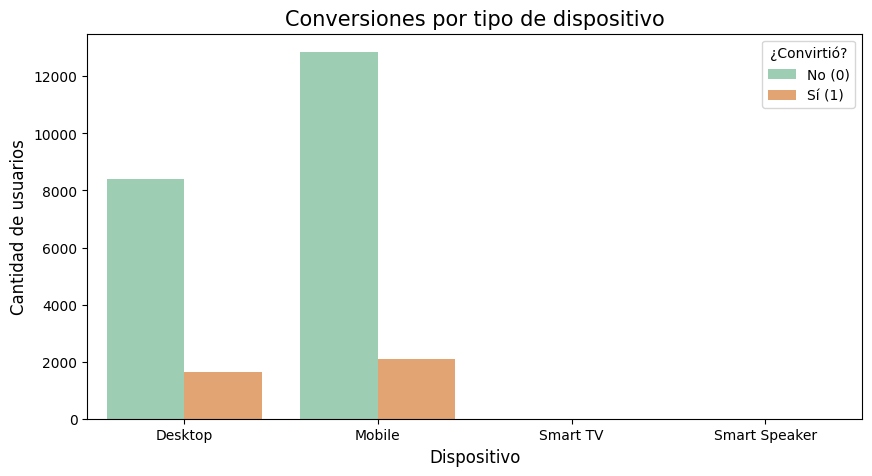

In [3]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='dispositivo', hue='conversion', palette = ["#95D5B2", "#F4A261"])

# Añadir detalles
plt.title('Conversiones por tipo de dispositivo', fontsize=15)
plt.xlabel('Dispositivo', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

Podemos ver que Mobile es el canal principal y que las conversiones entre "Desktop" y "Mobile" son similares, pero ¿qué tan similares son?

Para responder esta pregunta, podemos agregar los valores que cada barra representa.

Para esto, comenzamos guardando el gráfico countplot en la variable ax para usarlo después

Ahora, con el bucle, recorremos todas las barras del gráfico usando ax.patches.

Para cada barra, obtenemos su altura, que representa el número de usuarios,
Luego, definimos la coordenada en X, tomando como referencia el inicio de la barra.
Después, establecemos la coordenada en Y usando la altura de la barra.
Finalmente, indicamos que queremos mostrar ese valor, es decir, la cantidad de usuarios.
Para mejorar la vista, agregamos más espacio en el borde superior del gráfico usando ylim().

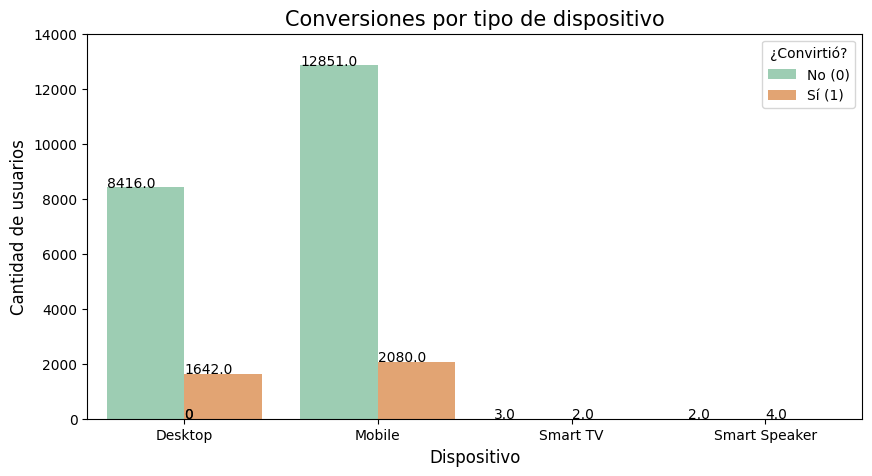

In [4]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='dispositivo', hue='conversion', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de la barra (conteo de usuarios)
    ax.text(x=bar.get_x(),          # Establecer coordenada X del texto (inicio de la barra)
            y=height,               # Establecer coordenada Y del texto (parte superior de la barra)
            s=height)               # Valor numérico a mostrar

# Añadir detalles
plt.title('Conversiones por tipo de dispositivo', fontsize=15)
plt.xlabel('Dispositivo', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,14000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

El valor está listo; pasemos a mejorar cómo se ve en el gráfico:

Primero, ajustamos la posición en el eje X para que la coordenada esté en el centro de cada barra.



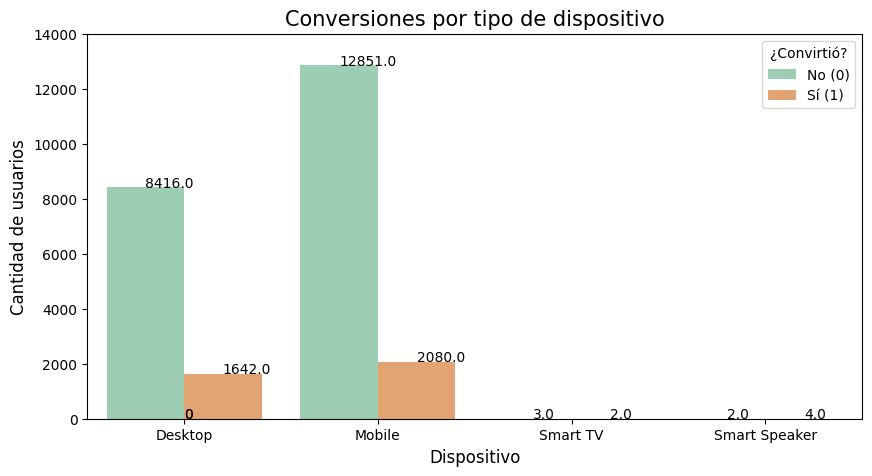

In [5]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='dispositivo', hue='conversion', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height)                         # Valor a mostrar

# Añadir detalles
plt.title('Conversiones por tipo de dispositivo', fontsize=15)
plt.xlabel('Dispositivo', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,14000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

Después, alineamos el texto al centro de esa coordenada con el parámetro ha.

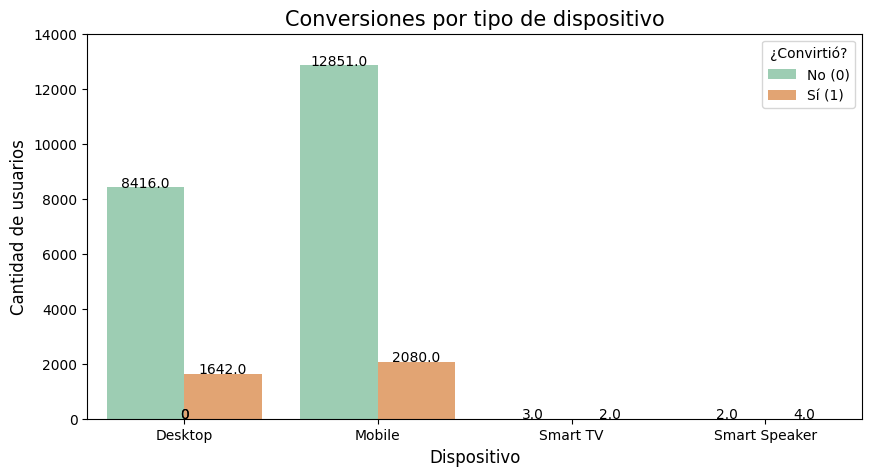

In [6]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='dispositivo', hue='conversion', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center')                      # Alinear centro del texto en coordenada

# Añadir detalles
plt.title('Conversiones por tipo de dispositivo', fontsize=15)
plt.xlabel('Dispositivo', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,14000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

Finalmente, alineamos la parte inferior del texto a la coordenada y agrandamos ligeramente su tamaño.

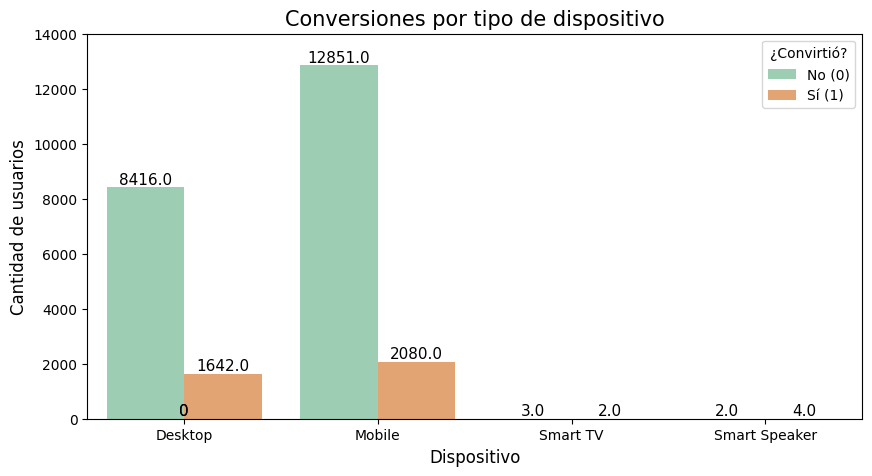

In [7]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='dispositivo', hue='conversion', palette = ["#95D5B2", "#F4A261"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='bottom',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Añadir detalles
plt.title('Conversiones por tipo de dispositivo', fontsize=15)
plt.xlabel('Dispositivo', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,14000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

#5.2.  Gráfico de barras apiladas en Python


A continuación, veamos cómo una misma tabla puede contar historias distintas según el gráfico.

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/content/landing_experiment_synthetic_3.csv")

# Tabla de contingencia normalizada
tabla = pd.crosstab(df['dispositivo'], df['conversion'], normalize='index') * 100
tabla

conversion,0,1
dispositivo,,
Desktop,83.674687,16.325313
Mobile,86.069252,13.930748
Smart Speaker,33.333333,66.666667
Smart TV,60.000000,40.000000


En esta tabla, no vemos quién es más grande, sino quién es más eficiente dentro de cada grupo.

Graficamos estos porcentajes y establecemos el parámetro stacked en True para apilar las barras

<Axes: xlabel='dispositivo'>

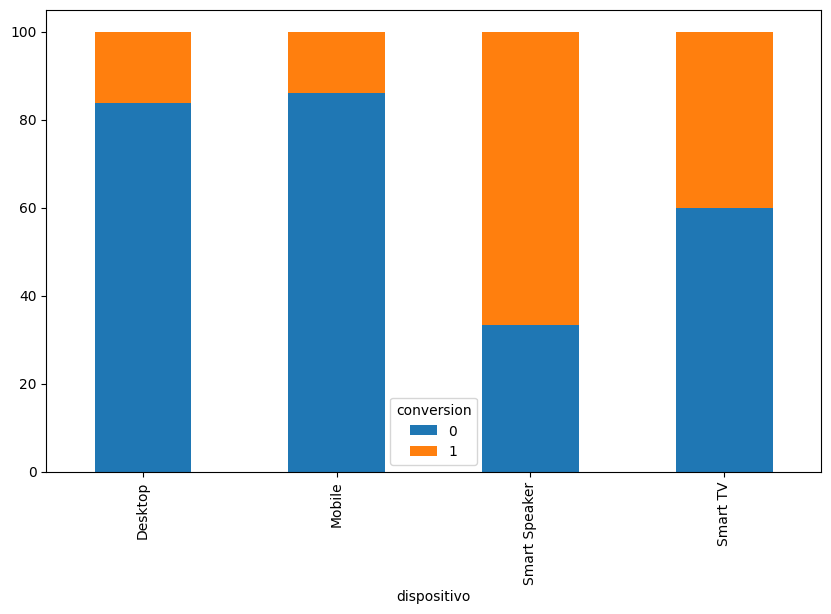

In [9]:
# Gráfica de barras apiladas
tabla.plot(kind='bar', stacked=True, figsize=(10, 6))

Mejoramos la vista cambiando los colores, para alinearlos con los del negocio; agregamos el título del gráfico, así como la etiqueta del eje Y y del eje X.

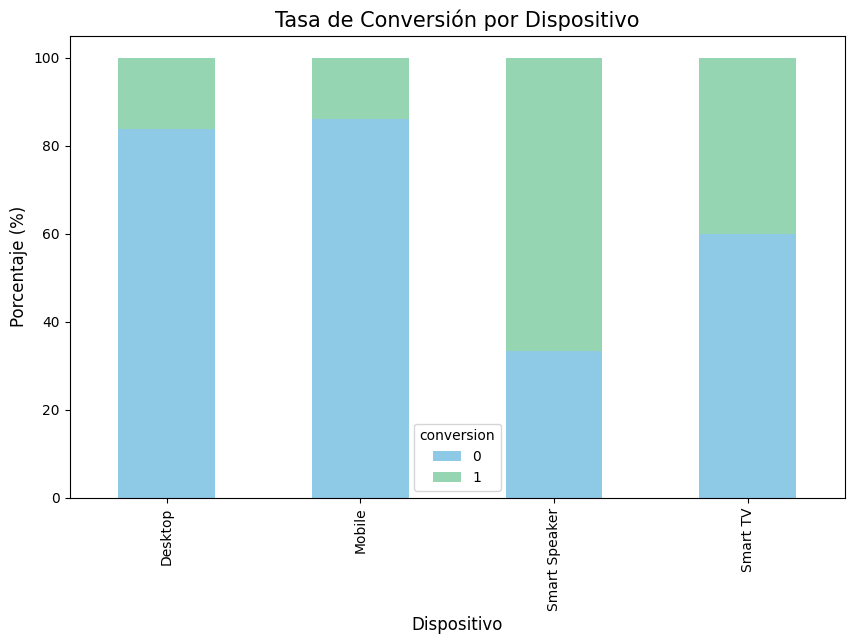

In [10]:
# Gráfica de barras apiladas
tabla.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por Dispositivo', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Dispositivo', fontsize=12)
plt.show()

La leyenda aparece por defecto en medio de la gráfica, pero podemos moverla de lugar.

Como primera opción, usando plt.legend(), la ubicamos afuera del gráfico.

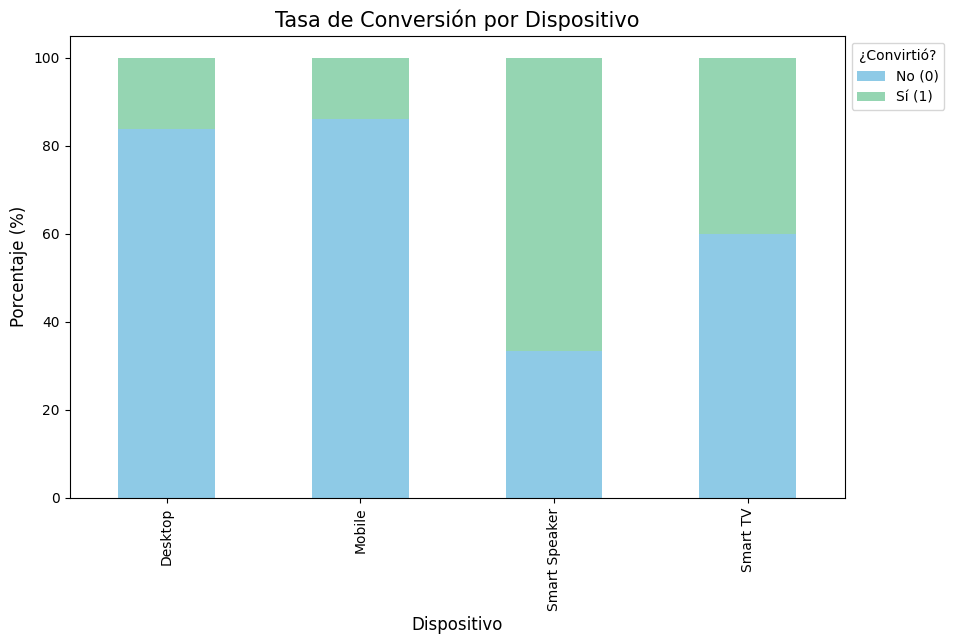

In [11]:
# Gráfica de barras apiladas
tabla.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por Dispositivo', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Dispositivo', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Otra opción es guardar el gráfico en la variable ax, agrandar el espacio en el eje X y ubicar las leyendas dentro del espacio del gráfico. Ambas opciones son válidas.

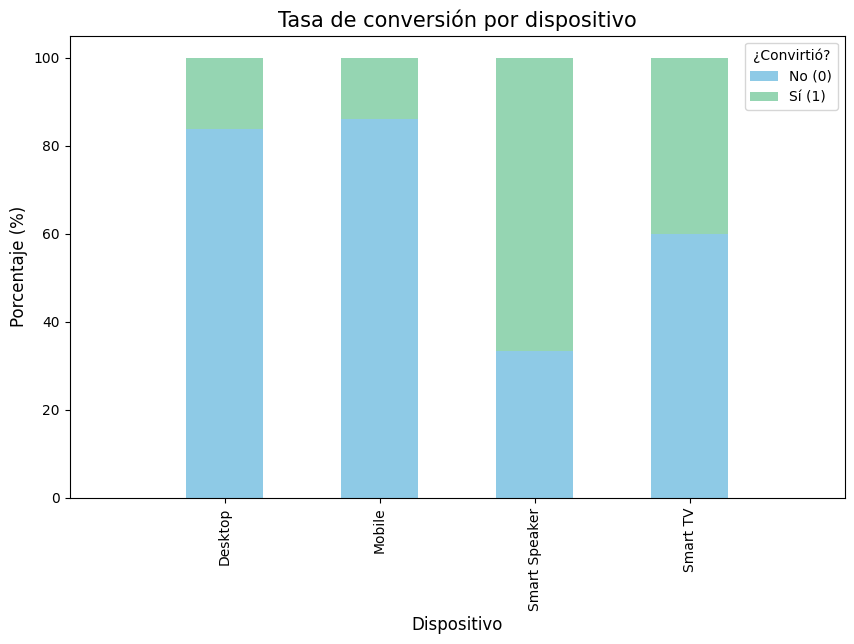

In [12]:
# Gráfica de barras apiladas
ax = tabla.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de conversión por dispositivo', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Dispositivo', fontsize=12)
ax.set_xlim(-1, 4)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.show()

A continuación, para tener la imagen completa, mostraremos ambos gráficos usando subplots().

Observa que indicamos 1 y 2, es decir, un renglón y dos columnas.

Primero, reutilizamos el código del gráfico de barras agrupadas, pero ahora le pasamos axes[0] para colocarlo en la primera posición.
Después, agregamos el código del gráfico de barras apiladas y usamos axes[1] para ubicarlo en la segunda posición.

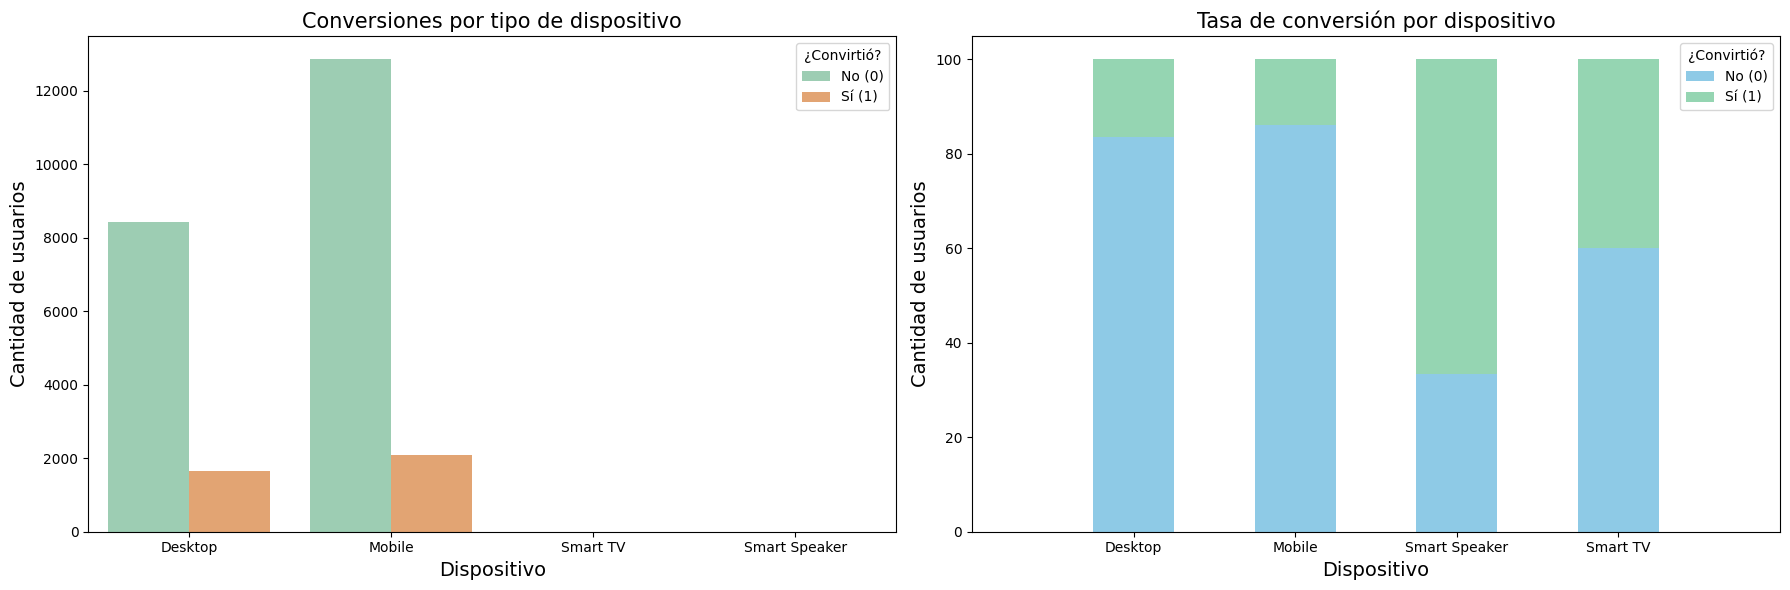

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barras agrupadas
# -----------------------------
sns.countplot(data=df, x='dispositivo', hue='conversion', palette=["#95D5B2", "#F4A261"], ax=axes[0])

axes[0].set_title('Conversiones por tipo de dispositivo', fontsize=15)
axes[0].set_xlabel('Dispositivo', fontsize=14)
axes[0].set_ylabel('Cantidad de usuarios', fontsize=14)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

# Barras apiladas
# -----------------------------
tabla.plot(kind='bar', stacked=True, color=["#8ecae6", "#95d5b2"], ax=axes[1])

axes[1].set_title('Tasa de conversión por dispositivo', fontsize=15)
axes[1].set_xlabel('Dispositivo', fontsize=14)
axes[1].set_ylabel('Cantidad de usuarios', fontsize=14)
axes[1].set_xlim(-1, 4)
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

En el primer gráfico, Smart TV y Smart Speaker no se ven porque su volumen es muy bajo. Sin embargo, en el gráfico de la derecha, Smart TV destaca por su proporción de conversión. Este tipo de gráfico revela patrones que el volumen total suele ocultar.

Entonces:

**Si necesitas saber cuántas personas, usa conteos.
Si quieres decidir dónde invertir, usa porcentajes.
Recuerda: los datos son los mismos, la historia depende de ti.**